In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function, plot_full_connectivity_tree_style

from critical_points.torch_critical_point_finder import find_critical_points_torch, save_critical_points_to_csv
from test_schwefel.schwefel_function_nnmodule import Schwefel2D, schwefel_loss, schwefel2D_numpy 

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
model_builder = lambda p: Schwefel2D(*p)

In [3]:
# Set parameters
BOUNDS = {'x1': (0.0, 1.0), 'x2': (0.0, 1.0)}
DIM = 2
ATTEMPTS = 1024
MIN_DISTANCE = 0.01


In [4]:
try:
    resume_df = pd.read_csv("critical_points_schwefel.csv", index_col=0)
    resume_df = resume_df[resume_df['type']=='minimum']
    display(resume_df)
except FileNotFoundError:
    resume_df = None


,x1,x2,f_value,type
0,0.341809,0.824375,0.181697,minimum
1,0.341809,0.341809,0.398836,minimum
2,0.034551,0.034551,0.675253,minimum
3,0.824375,0.824375,-0.035443,minimum
4,0.341809,0.034551,0.537045,minimum
5,0.034551,0.341809,0.537045,minimum
6,0.824375,0.341809,0.181697,minimum
7,0.824375,0.034551,0.319905,minimum
8,0.034551,0.824375,0.319905,minimum


In [5]:
minima, maxima, saddles = find_critical_points_torch(
    model_builder=model_builder,
    minima_only=True,
    loss_func=schwefel_loss,
    input = [],             # placeholder model input for compatibility (Schwefel model has no model input)
    bounds=BOUNDS,
    dimension=DIM,
    num_attempts=ATTEMPTS,
    min_distance=MIN_DISTANCE,
    device="cpu",
    lr=5e-2,
    max_iter=5_000,
    resume_df=resume_df,  # 👈 here!
    seed=1101
)



Loaded 9 valid points from dataframe.
Resuming with 9 loaded points.

__________________________________________________________________________________________
Attempt 1/1024:
Starting point: [0.25317813 0.88321528]
Arrival point: [0.34180915 0.82437793]
check grad: tensor([-1.5548e-05,  1.4999e-04])
tensor(0.0002)
Converged to critical point with ||grad||=1.51e-04 < 1e-05
Point [0.34180915 0.82437793] is too close to existing minimum at [0.34180945 0.82437499] (distance 0.000003 < 0.01)
Point [0.34180915 0.82437793] is too close to existing minimum. Rejecting.

__________________________________________________________________________________________
Attempt 2/1024:
Starting point: [0.76250551 0.35659261]
Arrival point: [0.82437273 0.34181001]
check grad: tensor([-1.1582e-04,  2.8709e-05])
tensor(0.0001)
Converged to critical point with ||grad||=1.19e-04 < 1e-05
Point [0.82437273 0.34181001] is too close to existing minimum at [0.82437499 0.34180945] (distance 0.000002 < 0.01)
Point

In [6]:
# Save to CSV
results_df = save_critical_points_to_csv(minima, maxima, saddles, dimension=DIM, filename="critical_points_schwefel_torch.csv")

results_df = pd.concat((resume_df,results_df), ignore_index=True)

display(results_df)

Saved critical_points_schwefel_torch.csv


,x1,x2,f_value,type
0,0.341809,0.824375,0.181697,minimum
1,0.341809,0.341809,0.398836,minimum
2,0.034551,0.034551,0.675253,minimum
3,0.824375,0.824375,-0.035443,minimum
4,0.341809,0.034551,0.537045,minimum
5,0.034551,0.341809,0.537045,minimum
6,0.824375,0.341809,0.181697,minimum
7,0.824375,0.034551,0.319905,minimum
8,0.034551,0.824375,0.319905,minimum


/tmp/ipykernel_731422/2176601272.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


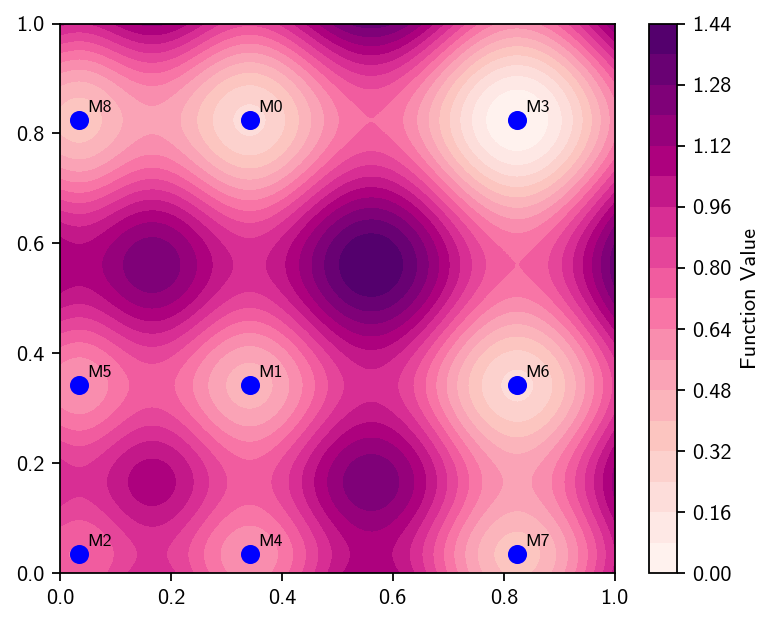

In [7]:
fig2 = plt.figure(figsize=(5,4), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_df=results_df,
                                connectivity_df=None, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
plt.xlim(*BOUNDS['x1'])
plt.ylim(*BOUNDS['x2'])
fig2.show()
# fig2.savefig("plots/landscape_paths.png")  # Optional